In [161]:
import pandas as pd

url = "/content/movie_dataset.csv"
df = pd.read_csv(url, engine='python')

X = df.drop(["homepage","id","overview","spoken_languages","status","tagline","crew"], axis=1)
y_reg = df["vote_average"]
y_class = df["vote_average"]

print(df.head())
print(X.head())

   index     budget                                    genres  \
0      0  237000000  Action Adventure Fantasy Science Fiction   
1      1  300000000                  Adventure Fantasy Action   
2      2  245000000                    Action Adventure Crime   
3      3  250000000               Action Crime Drama Thriller   
4      4  260000000          Action Adventure Science Fiction   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  culture clash future space war space colony so...                en   
1  ocean drug abuse exotic island east india trad...                en   
2         spy based on novel sec

In [162]:
print(df.isnull().sum())

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64


In [163]:
print(df.describe())

             index        budget             id   popularity       revenue  \
count  4803.000000  4.803000e+03    4803.000000  4803.000000  4.803000e+03   
mean   2401.000000  2.904504e+07   57165.484281    21.492301  8.226064e+07   
std    1386.651002  4.072239e+07   88694.614033    31.816650  1.628571e+08   
min       0.000000  0.000000e+00       5.000000     0.000000  0.000000e+00   
25%    1200.500000  7.900000e+05    9014.500000     4.668070  0.000000e+00   
50%    2401.000000  1.500000e+07   14629.000000    12.921594  1.917000e+07   
75%    3601.500000  4.000000e+07   58610.500000    28.313505  9.291719e+07   
max    4802.000000  3.800000e+08  459488.000000   875.581305  2.787965e+09   

           runtime  vote_average    vote_count  
count  4801.000000   4803.000000   4803.000000  
mean    106.875859      6.092172    690.217989  
std      22.611935      1.194612   1234.585891  
min       0.000000      0.000000      0.000000  
25%      94.000000      5.600000     54.000000  
50%

In [164]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = [
    "budget",
    "popularity",
    "revenue",
    "runtime",
    "vote_average",
    "vote_count"
]

X[numerical_cols] = scaler.fit_transform(
    X[numerical_cols]
)

print(X[numerical_cols].describe())

             budget   popularity      revenue       runtime  vote_average  \
count  4.803000e+03  4803.000000  4803.000000  4.801000e+03  4.803000e+03   
mean  -4.733993e-17     0.000000     0.000000  7.103947e-17 -3.668844e-16   
std    1.000104e+00     1.000104     1.000104  1.000104e+00  1.000104e+00   
min   -7.133192e-01    -0.675575    -0.505162 -4.727017e+00 -5.100238e+00   
25%   -6.939175e-01    -0.528842    -0.505162 -5.694869e-01 -4.120357e-01   
50%   -3.449331e-01    -0.269406    -0.387439 -1.714255e-01  9.027170e-02   
75%    2.690436e-01     0.214413     0.065442  4.920101e-01  5.925790e-01   
max    8.619128e+00    26.846885    16.615709  1.022240e+01  3.271552e+00   

         vote_count  
count  4.803000e+03  
mean  -4.733993e-17  
std    1.000104e+00  
min   -5.591266e-01  
25%   -5.153827e-01  
50%   -3.687596e-01  
75%    3.789682e-02  
max    1.058099e+01  


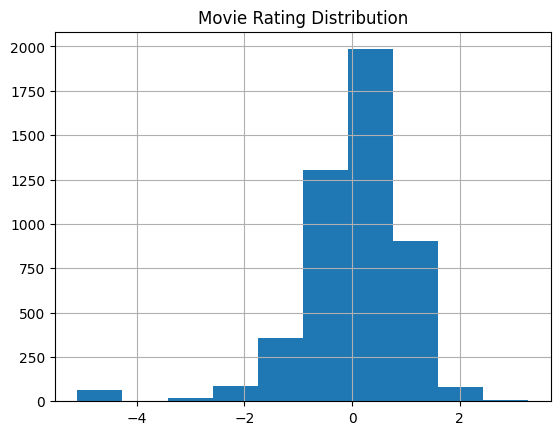

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

X["vote_average"].hist()

plt.title("Movie Rating Distribution")

plt.show()

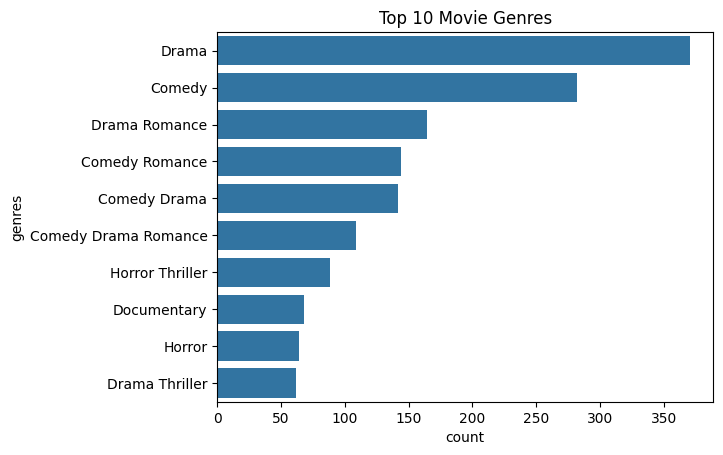

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    y="genres",
    data=df,
    order=df['genres'].value_counts().iloc[:10].index
)

plt.title("Top 10 Movie Genres")

plt.show()

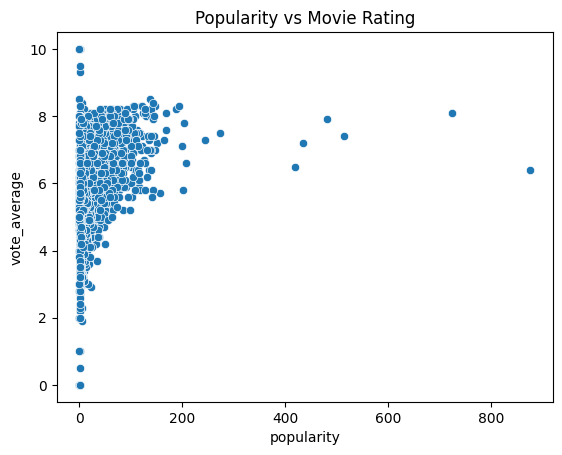

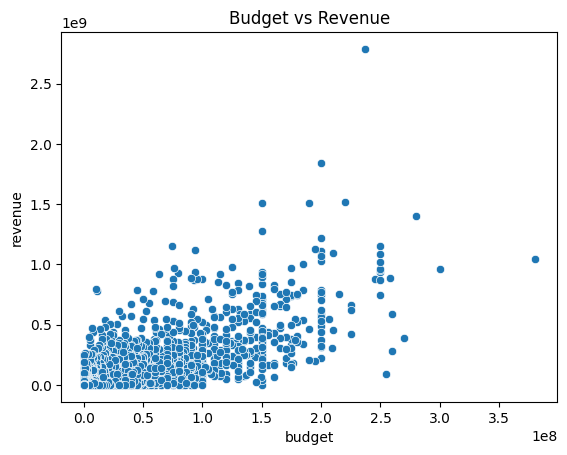

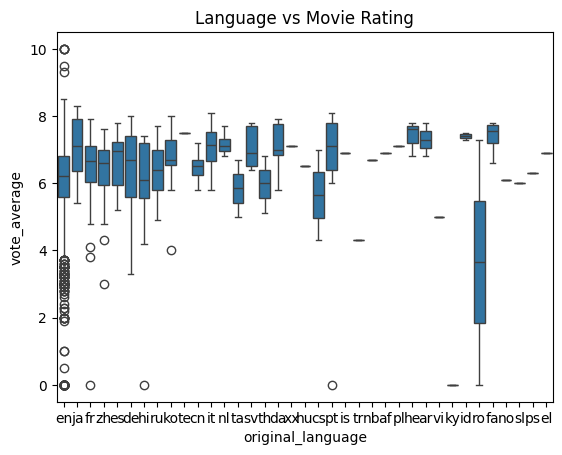

In [167]:
sns.scatterplot(
    x=df["popularity"],
    y=df["vote_average"]
)

plt.title("Popularity vs Movie Rating")

plt.show()

sns.scatterplot(
    x=df["budget"],
    y=df["revenue"]
)

plt.title("Budget vs Revenue")

plt.show()

sns.boxplot(
    x=df["original_language"],
    y=df["vote_average"]
)

plt.title("Language vs Movie Rating")

plt.show()

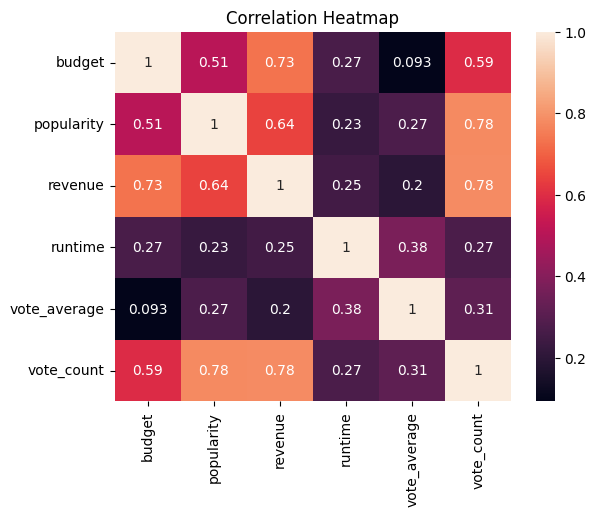

In [168]:
corr = df[[
    "budget",
    "popularity",
    "revenue",
    "runtime",
    "vote_average",
    "vote_count"
]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

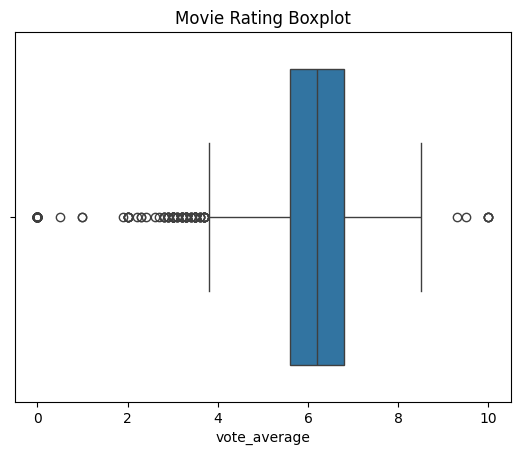

In [169]:
sns.boxplot(x=df["vote_average"])

plt.title("Movie Rating Boxplot")

plt.show()

In [170]:
import pandas as pd

df = pd.read_csv("/content/movie_dataset.csv")

Lab 7 : Data Cleaning, Encoding, Scaling, Train–Test Split, Feature Engineering, and Feature Selection P1: 08-04-2026

In [171]:
import pandas as pd

df = pd.read_csv("/content/movie_dataset.csv")
X = df.drop([
    "homepage",
    "id",
    "overview",
    "spoken_languages",
    "status",
    "tagline"
], axis=1)
y_reg = df["vote_average"]

In [172]:
# Check missing values
print(X.isnull().sum())

index                     0
budget                    0
genres                   28
keywords                412
original_language         0
original_title            0
popularity                0
production_companies      0
production_countries      0
release_date              1
revenue                   0
runtime                   2
title                     0
vote_average              0
vote_count                0
cast                     43
crew                      0
director                 30
dtype: int64


In [173]:
# Fill missing text values

X["genres"] = X["genres"].fillna("")

X["keywords"] = X["keywords"].fillna("")

X["cast"] = X["cast"].fillna("")

X["director"] = X["director"].fillna("")

In [174]:
# Fill missing numeric values

X["runtime"] = X["runtime"].fillna(
    X["runtime"].mean()
)

X["release_date"] = X["release_date"].fillna(
    "Unknown"
)

In [175]:
# Re-check missing values
print(X.isnull().sum())

index                   0
budget                  0
genres                  0
keywords                0
original_language       0
original_title          0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
title                   0
vote_average            0
vote_count              0
cast                    0
crew                    0
director                0
dtype: int64


In [176]:
# Create New Feature

X["Movie_Score"] = (
    X["vote_average"] +
    X["popularity"]
) / 2

In [177]:
import pandas as pd

# Combine for correlation

temp_df = X.copy()

temp_df["Movie_Score"] = y_reg

corr = temp_df.corr(numeric_only=True)

print(
    corr["Movie_Score"].sort_values(
        ascending=False
    )
)

Movie_Score     1.000000
vote_average    1.000000
runtime         0.373989
vote_count      0.312997
popularity      0.273952
revenue         0.197150
budget          0.093146
index          -0.120157
Name: Movie_Score, dtype: float64


In [178]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

 Baseline ML Model Implementation using scikit-learn

In [179]:
# Remove rows with missing genres

df = df.dropna(subset=["genres"])

In [180]:
df = df.dropna(
    subset=[
        "genres",
        "keywords",
        "cast"
    ]
)

In [181]:
print(df.isnull().sum())

index                      0
budget                     0
genres                     0
homepage                2764
id                         0
keywords                   0
original_language          0
original_title             0
overview                   2
popularity                 0
production_companies       0
production_countries       0
release_date               0
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  622
title                      0
vote_average               0
vote_count                 0
cast                       0
crew                       0
director                   3
dtype: int64


In [182]:
# Fill missing text values

df["genres"] = df["genres"].fillna("Unknown")

df["keywords"] = df["keywords"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Unknown")

df["director"] = df["director"].fillna("Unknown")

In [183]:
df["runtime"] = df["runtime"].fillna(
    df["runtime"].median()
)

In [184]:
print(df.isnull().sum())

index                      0
budget                     0
genres                     0
homepage                2764
id                         0
keywords                   0
original_language          0
original_title             0
overview                   2
popularity                 0
production_companies       0
production_countries       0
release_date               0
revenue                    0
runtime                    0
spoken_languages           0
status                     0
tagline                  622
title                      0
vote_average               0
vote_count                 0
cast                       0
crew                       0
director                   0
dtype: int64


In [185]:
df["homepage"] = df["homepage"].fillna("Unknown")
df["overview"] = df["overview"].fillna("Unknown")
df["tagline"] = df["tagline"].fillna("Unknown")
df["runtime"] = df["runtime"].fillna(df["runtime"].median())
df["director"] = df["director"].fillna("Unknown")

In [186]:
print(df.isnull().sum())

index                   0
budget                  0
genres                  0
homepage                0
id                      0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
status                  0
tagline                 0
title                   0
vote_average            0
vote_count              0
cast                    0
crew                    0
director                0
dtype: int64


In [187]:
X["runtime"] = X["runtime"].fillna(X["runtime"].median())

X["director"] = X["director"].fillna("Unknown")

In [188]:
print(X.isnull().sum())

index                   0
budget                  0
genres                  0
keywords                0
original_language       0
original_title          0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
title                   0
vote_average            0
vote_count              0
cast                    0
crew                    0
director                0
Movie_Score             0
dtype: int64


In [189]:
X["release_date"] = X["release_date"].fillna("Unknown")

X["runtime"] = X["runtime"].fillna(X["runtime"].median())

In [190]:
print(X.isnull().sum())

index                   0
budget                  0
genres                  0
keywords                0
original_language       0
original_title          0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
title                   0
vote_average            0
vote_count              0
cast                    0
crew                    0
director                0
Movie_Score             0
dtype: int64


Feature Engineering

In [191]:
X["Movie_Score"] = (X["popularity"] + X["vote_count"]) / 2

In [192]:
print(X["Movie_Score"].head())

0    5975.218789
1    2319.541308
2    2286.688394
3    4609.156475
4    1083.963497
Name: Movie_Score, dtype: float64


In [193]:
print(X["Movie_Score"].describe())

count    4803.000000
mean      355.855145
std       629.750964
min         0.000000
25%        29.427594
50%       124.372780
75%       383.625282
max      6959.791855
Name: Movie_Score, dtype: float64


Feature Target Separation

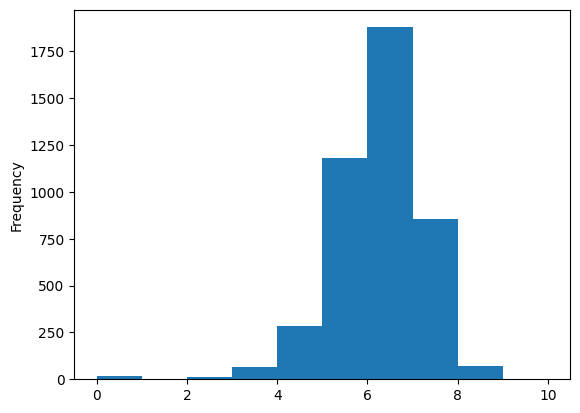

In [194]:
import matplotlib.pyplot as plt

df["vote_average"].plot(kind="hist")
plt.show()

lab 10

In [195]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [196]:
# Text columns remove karo
# X = X.drop(['genres','keywords'], axis=1) # This line caused the error as 'genres' and 'keywords' were already removed or never present in X.

# Remove the target variable 'vote_average' from features X
if 'vote_average' in X.columns:
    X = X.drop('vote_average', axis=1)

# Sirf numeric columns rakho
X = X.select_dtypes(include=['int64','float64'])

from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

print(y_pred_reg[:10])

[5.55526385 5.75276661 5.67743051 6.12792413 7.00931403 5.97024174
 6.31735921 6.2437365  5.84828302 5.72464455]


In [197]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)

print("R2 Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R2 Score : 0.22779930311454533
MAE : 0.6973196939300831
MSE : 1.16435308815564
RMSE : 1.0790519395078442


In [198]:
print("Actual Ratings:")
print(y_test_reg.head(10))

print("Predicted Ratings:")
print(y_pred_reg[:10])

Actual Ratings:
596     5.2
3372    5.7
2702    5.5
2473    6.7
8       7.4
577     5.5
3172    6.7
811     6.6
2077    6.7
4032    6.0
Name: vote_average, dtype: float64
Predicted Ratings:
[5.55526385 5.75276661 5.67743051 6.12792413 7.00931403 5.97024174
 6.31735921 6.2437365  5.84828302 5.72464455]


In [199]:
from sklearn.model_selection import train_test_split

# Create a copy of X for classification processing to avoid modifying the original X
X_cls_processed = X.copy()

# Drop 'vote_average' from features as it is the target variable (y_class)
# Ensure it's dropped only if it exists in the DataFrame
if 'vote_average' in X_cls_processed.columns:
    X_cls_processed = X_cls_processed.drop('vote_average', axis=1)

# Select only numerical features for the classification model
X_cls_processed = X_cls_processed.select_dtypes(include=['int64', 'float64'])

# Fill any remaining NaN values in the numerical features with the mean of their columns
X_cls_processed = X_cls_processed.fillna(X_cls_processed.mean())

# Perform the train-test split for classification using the processed X
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_processed, y_class, test_size=0.2, random_state=42
)

In [200]:
from sklearn.linear_model import LogisticRegression

# Convert continuous target (y_class) to binary classes for classification
# For example, classify movies with vote_average >= 7.0 as 'good' (1) and others as 'bad' (0)
threshold = 7.0
y_train_cls_binary = (y_train_cls >= threshold).astype(int)
y_test_cls_binary = (y_test_cls >= threshold).astype(int)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_cls, y_train_cls_binary) # Use the binary target for fitting

y_pred_log = log_model.predict(X_test_cls)

In [201]:
from sklearn.linear_model import LogisticRegression

# Convert continuous target (y_class) to binary classes for classification
# For example, classify movies with vote_average >= 7.0 as 'good' (1) and others as 'bad' (0)
threshold = 7.0
y_train_cls_binary = (y_train_cls >= threshold).astype(int)
y_test_cls_binary = (y_test_cls >= threshold).astype(int)

# Ensure X_train_cls and X_test_cls have no NaN values before fitting
# This step is added as a failsafe, as NaNs should ideally be handled during preprocessing.
X_train_cls_cleaned = X_train_cls.fillna(X_train_cls.mean())
X_test_cls_cleaned = X_test_cls.fillna(X_test_cls.mean())

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_cls_cleaned, y_train_cls_binary) # Use the binary target for fitting

y_pred_log = log_model.predict(X_test_cls_cleaned)

In [202]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test_cls_binary, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test_cls_binary, y_pred_log))
print(classification_report(y_test_cls_binary, y_pred_log))

Accuracy: 0.8220603537981269
Confusion Matrix:
 [[740  24]
 [147  50]]
              precision    recall  f1-score   support

           0       0.83      0.97      0.90       764
           1       0.68      0.25      0.37       197

    accuracy                           0.82       961
   macro avg       0.75      0.61      0.63       961
weighted avg       0.80      0.82      0.79       961



In [203]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test_cls_binary, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test_cls_binary, y_pred_log))
print(classification_report(y_test_cls_binary, y_pred_log))

Accuracy: 0.8220603537981269
Confusion Matrix:
 [[740  24]
 [147  50]]
              precision    recall  f1-score   support

           0       0.83      0.97      0.90       764
           1       0.68      0.25      0.37       197

    accuracy                           0.82       961
   macro avg       0.75      0.61      0.63       961
weighted avg       0.80      0.82      0.79       961



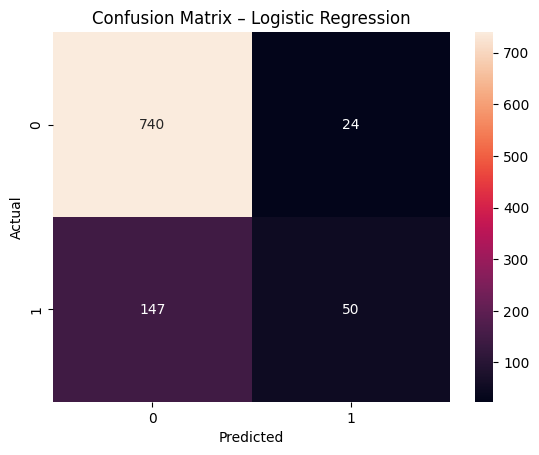

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls_binary, y_pred_log)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

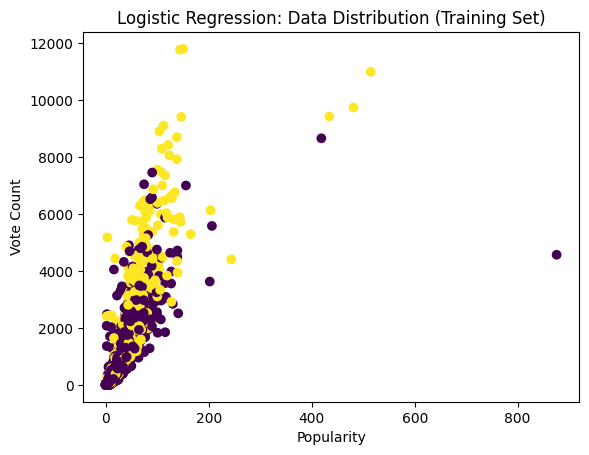

In [205]:
plt.scatter(X_train_cls["popularity"], X_train_cls["vote_count"], c=y_train_cls_binary)
plt.xlabel("Popularity")
plt.ylabel("Vote Count")
plt.title("Logistic Regression: Data Distribution (Training Set)")
plt.show()

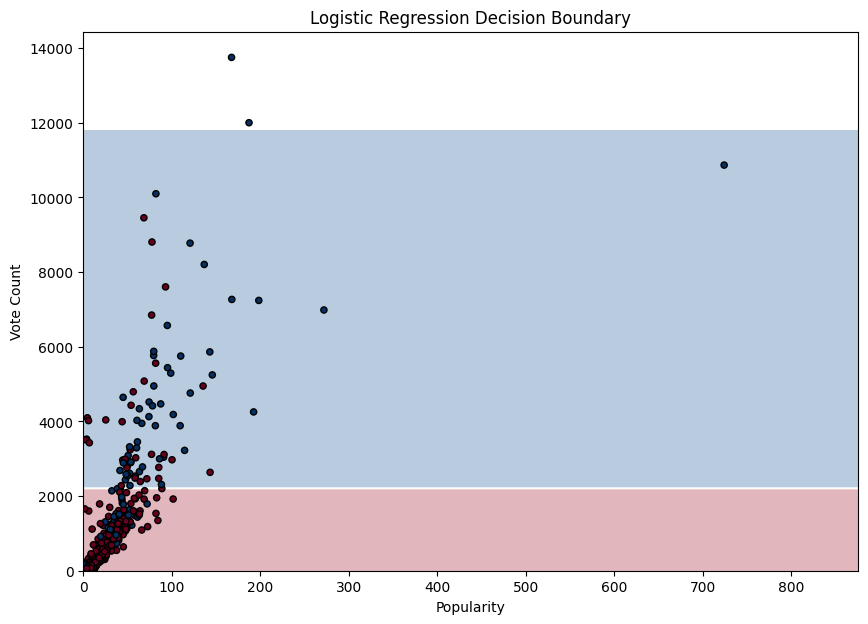

In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Choose two features from X_train_cls for the mesh grid
feature1 = "popularity"
feature2 = "vote_count"

# Create mesh grid (2 features only)
x_min, x_max = X_train_cls[feature1].min() - 0.1, X_train_cls[feature1].max() + 0.1
y_min, y_max = X_train_cls[feature2].min() - 0.1, X_train_cls[feature2].max() + 0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Step 1: Grid with 2 features
grid = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid, columns=[feature1, feature2])

# Step 2: Add remaining features with mean values from X_train_cls
# Get all columns from X_train_cls except the two selected for the grid
other_features = [col for col in X_train_cls.columns if col not in [feature1, feature2]]
for col in other_features:
    grid_df[col] = X_train_cls[col].mean()

# Step 3: Ensure correct column order for prediction
grid_df = grid_df[X_train_cls.columns]

# Step 4: Predict
Z = log_model.predict(grid_df)
Z = Z.reshape(xx.shape)

# Step 5: Plot decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# Plot actual test data
plt.scatter(
    X_test_cls[feature1],
    X_test_cls[feature2],
    c=y_test_cls_binary, # Use binary target for classification plot
    cmap=plt.cm.RdBu, # Use a diverging colormap for binary classes
    edgecolor='k', s=20
)

plt.xlabel(feature1.replace('_', ' ').title())
plt.ylabel(feature2.replace('_', ' ').title())
plt.title("Logistic Regression Decision Boundary")
plt.show()

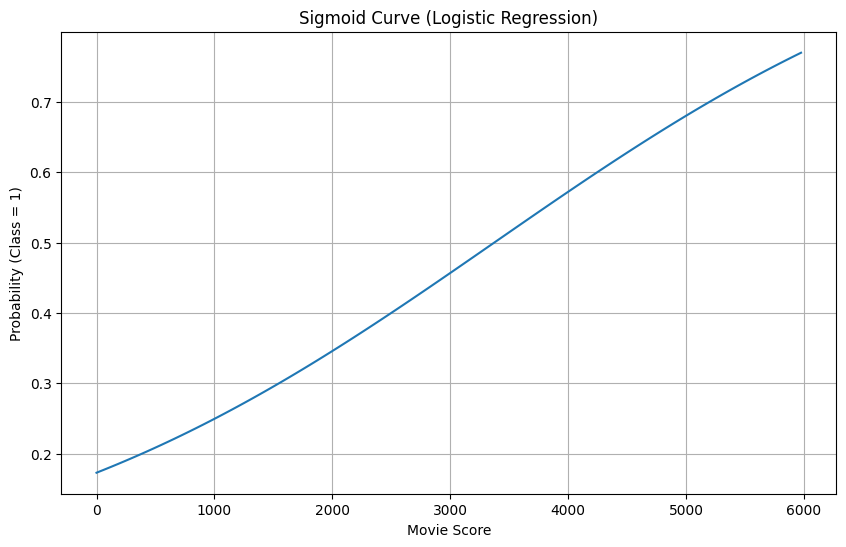

In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Choose a feature for the x-axis of the sigmoid curve
x_feature = "Movie_Score"

# Step 1: Create range for the chosen feature
x_range = np.linspace(
    X_train_cls[x_feature].min(),
    X_train_cls[x_feature].max(),
    100
)

# Step 2: Fix other features at mean
data_curve_dict = {x_feature: x_range}

# Get all columns from X_train_cls except the one chosen for the x-axis
other_features_for_curve = [col for col in X_train_cls.columns if col != x_feature]

for col in other_features_for_curve:
    data_curve_dict[col] = X_train_cls[col].mean()

data_curve = pd.DataFrame(data_curve_dict)

# Step 3: Ensure column order matches training
data_curve = data_curve[X_train_cls.columns]

# Step 4: Get probabilities for class 1
probs = log_model.predict_proba(data_curve)[:, 1]

# Step 5: Plot sigmoid curve
plt.figure(figsize=(10, 6))
plt.plot(x_range, probs)

plt.xlabel(x_feature.replace('_', ' ').title())
plt.ylabel("Probability (Class = 1)")
plt.title("Sigmoid Curve (Logistic Regression)")
plt.grid()
plt.show()

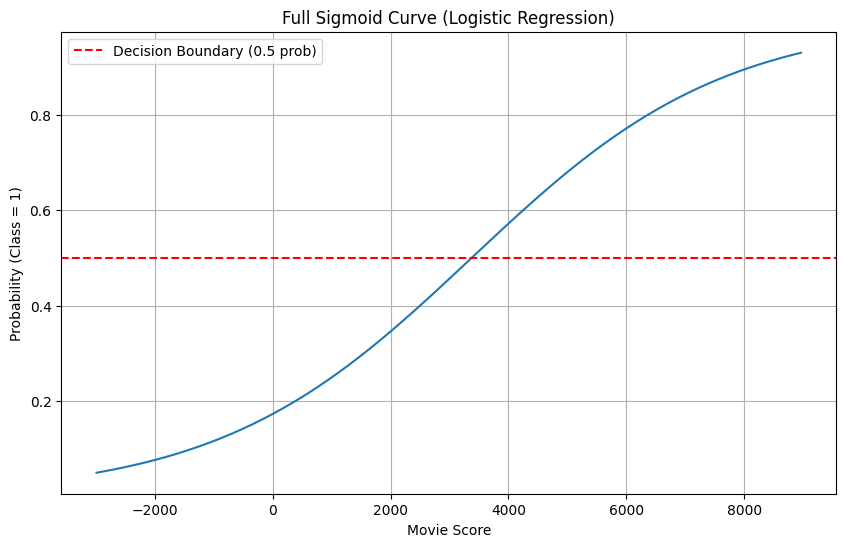

In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Choose a feature for the x-axis of the sigmoid curve
x_feature = "Movie_Score"

# Step 1: Extend range beyond actual data
x_range_extended = np.linspace(
    X_train_cls[x_feature].min() - (X_train_cls[x_feature].max() - X_train_cls[x_feature].min())*0.5,
    X_train_cls[x_feature].max() + (X_train_cls[x_feature].max() - X_train_cls[x_feature].min())*0.5,
    200
)

# Step 2: Keep other features constant (mean)
data_curve_dict = {x_feature: x_range_extended}

# Get all columns from X_train_cls except the one chosen for the x-axis
other_features_for_curve = [col for col in X_train_cls.columns if col != x_feature]

for col in other_features_for_curve:
    data_curve_dict[col] = X_train_cls[col].mean()

data_curve = pd.DataFrame(data_curve_dict)

# Step 3: Match column order
data_curve = data_curve[X_train_cls.columns]

# Step 4: Predict probabilities
probs = log_model.predict_proba(data_curve)[:, 1]

# Step 5: Plot
plt.figure(figsize=(10, 6))
plt.plot(x_range_extended, probs)

# Highlight decision boundary (where probability is 0.5)
plt.axhline(0.5, linestyle='--', color='red', label='Decision Boundary (0.5 prob)')

plt.xlabel(x_feature.replace('_', ' ').title())
plt.ylabel("Probability (Class = 1)")
plt.title("Full Sigmoid Curve (Logistic Regression)")
plt.grid(True)
plt.legend()
plt.show()

In [209]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
# Use the binary target for classification
nb_model.fit(X_train_cls, y_train_cls_binary)

y_pred_nb = nb_model.predict(X_test_cls)

In [210]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy (Naive Bayes):", accuracy_score(y_test_cls_binary, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test_cls_binary, y_pred_nb))
print("Classification Report:\n", classification_report(y_test_cls_binary, y_pred_nb))

Accuracy (Naive Bayes): 0.7783558792924038
Confusion Matrix:
 [[723  41]
 [172  25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.95      0.87       764
           1       0.38      0.13      0.19       197

    accuracy                           0.78       961
   macro avg       0.59      0.54      0.53       961
weighted avg       0.72      0.78      0.73       961



In [211]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_cls, y_train_cls_binary)

y_pred_nb = nb_model.predict(X_test_cls)

In [212]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy (Naive Bayes):", accuracy_score(y_test_cls_binary, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test_cls_binary, y_pred_nb))
print("Classification Report:\n", classification_report(y_test_cls_binary, y_pred_nb))

Accuracy (Naive Bayes): 0.7783558792924038
Confusion Matrix:
 [[723  41]
 [172  25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.95      0.87       764
           1       0.38      0.13      0.19       197

    accuracy                           0.78       961
   macro avg       0.59      0.54      0.53       961
weighted avg       0.72      0.78      0.73       961



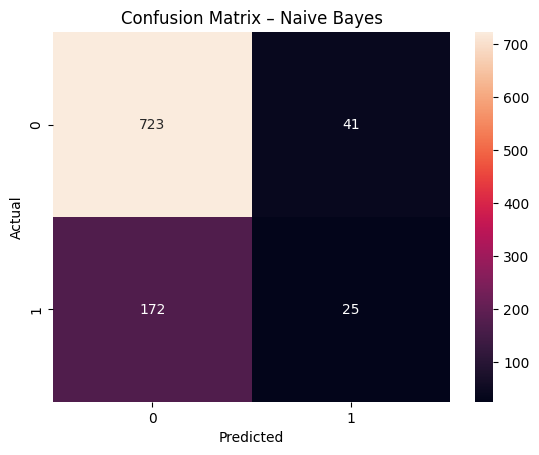

In [213]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test_cls_binary, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Confusion Matrix – Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

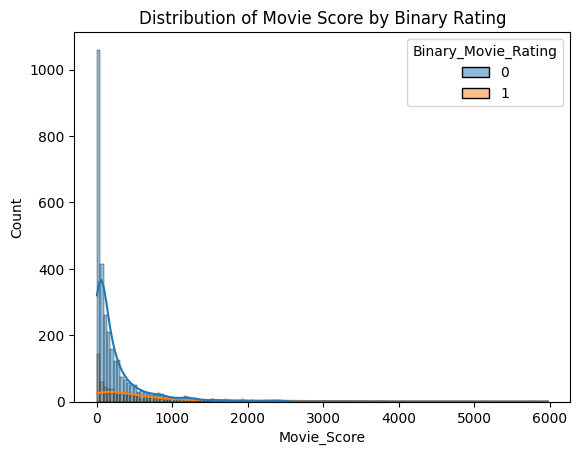

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary DataFrame for plotting, combining X_train_cls and y_train_cls_binary
plot_df = X_train_cls.copy()
plot_df['Binary_Movie_Rating'] = y_train_cls_binary

sns.histplot(data=plot_df, x="Movie_Score", hue="Binary_Movie_Rating", kde=True)
plt.title("Distribution of Movie Score by Binary Rating")
plt.show()

In [215]:
y_prob_nb = nb_model.predict_proba(X_test_cls)

print("Sample Probabilities:\n", y_prob_nb[:10].round(2))

Sample Probabilities:
 [[0.89 0.11]
 [0.9  0.1 ]
 [0.9  0.1 ]
 [0.89 0.11]
 [0.   1.  ]
 [0.85 0.15]
 [0.9  0.1 ]
 [0.59 0.41]
 [0.9  0.1 ]
 [0.9  0.1 ]]


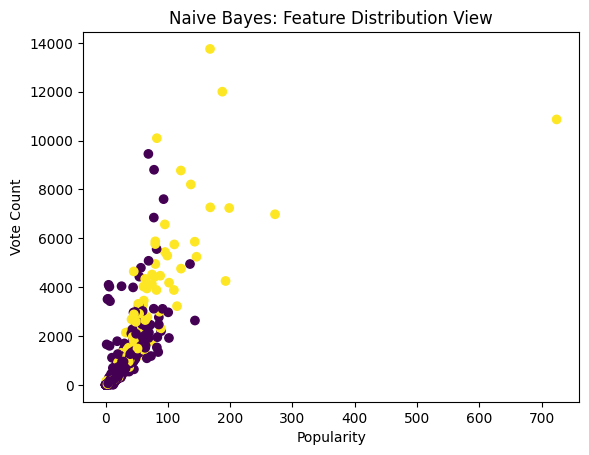

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(X_test_cls["popularity"], X_test_cls["vote_count"], c=y_test_cls_binary)
plt.xlabel("Popularity")
plt.ylabel("Vote Count")
plt.title("Naive Bayes: Feature Distribution View")
plt.show()

In [217]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_cls, y_train_cls_binary)

y_pred_knn = knn_model.predict(X_test_cls)

In [218]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy (k-NN):", accuracy_score(y_test_cls_binary, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test_cls_binary, y_pred_knn))
print("Classification Report:\n", classification_report(y_test_cls_binary, y_pred_knn))

Accuracy (k-NN): 0.7710718002081165
Confusion Matrix:
 [[703  61]
 [159  38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.86       764
           1       0.38      0.19      0.26       197

    accuracy                           0.77       961
   macro avg       0.60      0.56      0.56       961
weighted avg       0.73      0.77      0.74       961



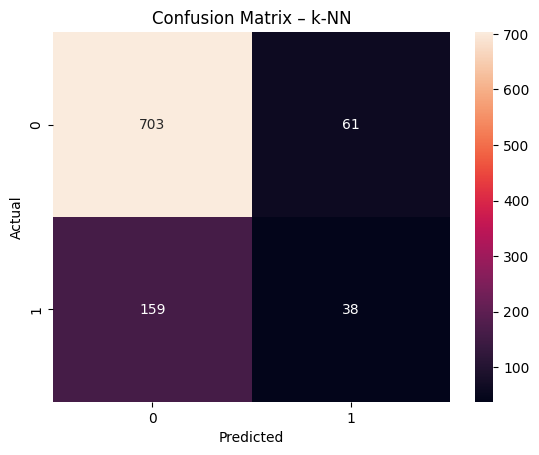

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test_cls_binary, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("Confusion Matrix – k-NN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

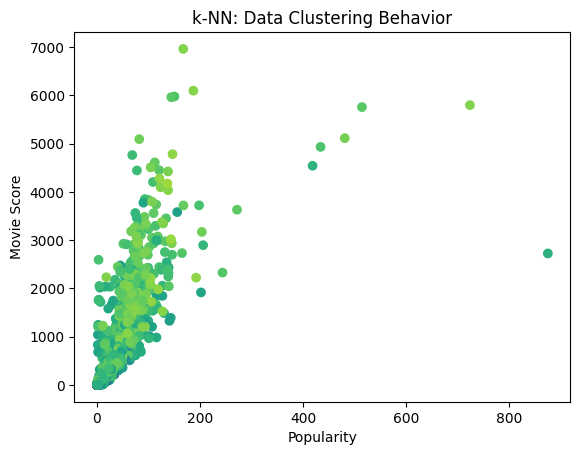

In [220]:
plt.scatter(X["popularity"], X["Movie_Score"], c=y_class)
plt.xlabel("Popularity")
plt.ylabel("Movie Score")
plt.title("k-NN: Data Clustering Behavior")
plt.show()

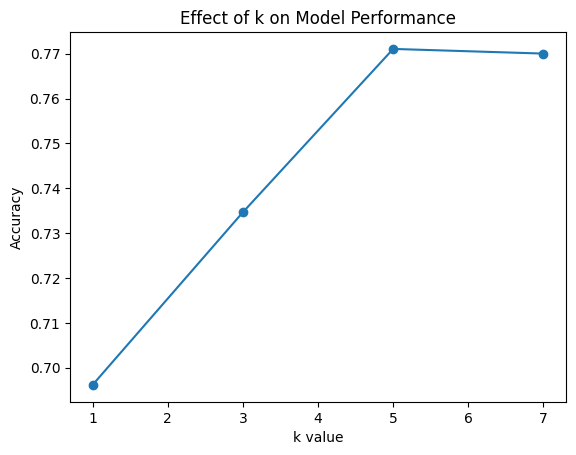

In [221]:
k_values = [1, 3, 5, 7]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_cls, y_train_cls_binary)
    pred = model.predict(X_test_cls)
    acc = accuracy_score(y_test_cls_binary, pred)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("Effect of k on Model Performance")
plt.show()

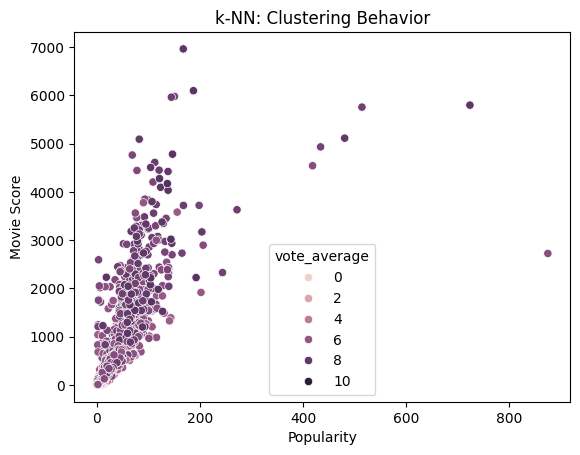

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=X["popularity"],
    y=X["Movie_Score"],
    hue=y_class
)

plt.title("k-NN: Clustering Behavior")
plt.xlabel("Popularity")
plt.ylabel("Movie Score")
plt.show()

In [223]:
import numpy as np

# Example: distance from first test point to all training points
distances = np.linalg.norm(X_train_cls - X_test_cls.iloc[0], axis=1)

print("Sample distances:", distances[:15].round(2))

Sample distances: [7.76295687e+07 5.90033190e+07 8.17282113e+07 7.52213123e+07
 5.00981884e+07 7.76295686e+07 7.76295687e+07 1.28627288e+08
 5.10056619e+07 2.77841594e+08 7.76295686e+07 5.99128156e+07
 1.03649551e+08 7.23122080e+07 7.76295687e+07]


In [224]:
print("Logistic Regression Accuracy:", accuracy_score(y_test_cls_binary, y_pred_log))
print("Naive Bayes Accuracy:", accuracy_score(y_test_cls_binary, y_pred_nb))
print("k-NN Accuracy:", accuracy_score(y_test_cls_binary, y_pred_knn))

Logistic Regression Accuracy: 0.8220603537981269
Naive Bayes Accuracy: 0.7783558792924038
k-NN Accuracy: 0.7710718002081165


### Model Accuracy Comparison

To easily compare the performance of the Logistic Regression, Naive Bayes, and k-NN classification models, we'll create a bar chart of their accuracy scores.

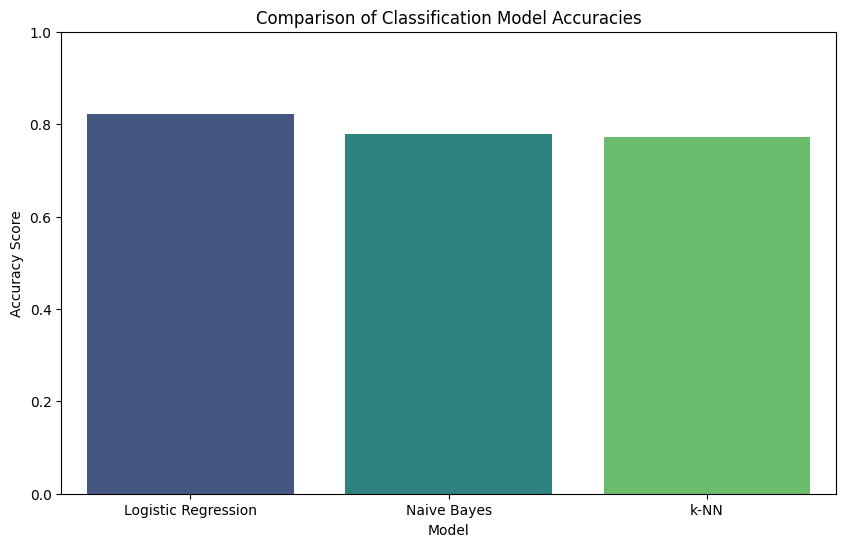

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Accuracy scores obtained from previous outputs
acc_log = 0.8220603537981269
acc_nb = 0.7783558792924038
acc_knn = 0.7710718002081165

# Create a DataFrame for plotting
accuracy_data = {
    'Model': ['Logistic Regression', 'Naive Bayes', 'k-NN'],
    'Accuracy': [acc_log, acc_nb, acc_knn]
}
accuracy_df = pd.DataFrame(accuracy_data)

# Plotting the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, hue='Model', palette='viridis', legend=False)
plt.title('Comparison of Classification Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.show()

### Save Cleaned Data

Now that the data has been cleaned and processed, we will save the `df` DataFrame to a new CSV file. This allows for easy reloading of the cleaned data in future sessions without needing to re-run all the preprocessing steps.

In [226]:
df.to_csv('cleaned_movie_dataset.csv', index=False)
print("Cleaned DataFrame saved to 'cleaned_movie_dataset.csv'")

Cleaned DataFrame saved to 'cleaned_movie_dataset.csv'


### Data Loading and Initial Feature DataFrame Creation

First, we'll load the dataset into a pandas DataFrame. Then, we'll create our feature set `X` by dropping columns that are not suitable for direct use as features (like text descriptions, IDs, or URLs). We'll also define `y_reg` and `y_class` as target variables for regression and classification tasks, respectively, both based on the 'vote_average' column.

In [227]:
import pandas as pd

url = "/content/movie_dataset.csv"
df = pd.read_csv(url)

# Define feature set X by dropping specified columns
X = df.drop([
    "homepage", "id", "overview", "spoken_languages",
    "status", "tagline", "crew","vote_average"
], axis=1)

# Define target variables for regression and classification
y_reg = df["vote_average"]
y_class = df["vote_average"]

print("Head of the original DataFrame (df):")
display(df.head())

print("\nHead of the features DataFrame (X):")
display(X.head())

Head of the original DataFrame (df):


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton



Head of the features DataFrame (X):


,index,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,title,vote_count,cast,director
0,0,237000000,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,en,Avatar,150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,Avatar,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron
1,1,300000000,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,Pirates of the Caribbean: At World's End,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski
2,2,245000000,Action Adventure Crime,spy based on novel secret agent sequel mi6,en,Spectre,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,Spectre,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes
3,3,250000000,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,The Dark Knight Rises,9106,Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,en,John Carter,43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,John Carter,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton


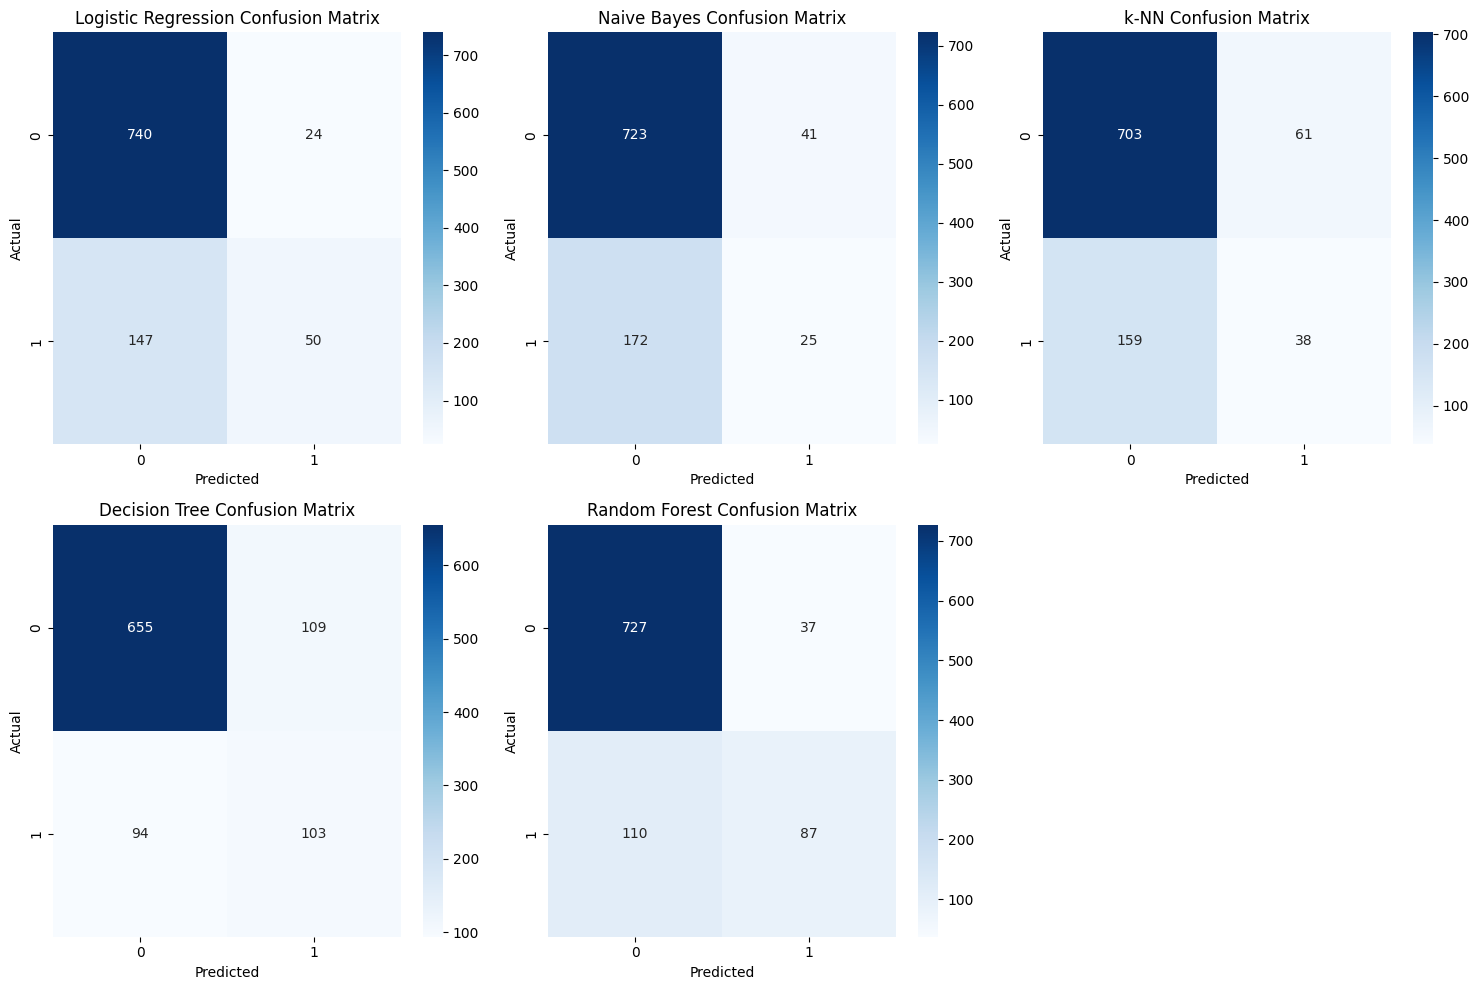

In [228]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import math

# The prediction variables y_pred_log, y_pred_nb, y_pred_knn, y_pred_dt, y_pred_rf
# and the true labels y_test_cls_binary are already available from previous cell executions.

models = {
    "Logistic Regression": y_pred_log,
    "Naive Bayes": y_pred_nb,
    "k-NN": y_pred_knn
}

# Dynamically add Decision Tree, Random Forest, and SVM if their predictions are available
if 'y_pred_dt' in globals():
    models["Decision Tree"] = y_pred_dt
if 'y_pred_rf' in globals():
    models["Random Forest"] = y_pred_rf
if 'y_pred_svm' in globals():
    models["SVM"] = y_pred_svm


plt.figure(figsize=(15, 10))
# Adjust subplot grid based on the number of available models
num_models = len(models)
rows = math.ceil(num_models / 3) # This ensures enough rows (e.g., 5 models -> 2 rows, 6 models -> 2 rows)
cols = 3 # Max 3 columns for better layout

for i, (name, pred) in enumerate(models.items()):
    plt.subplot(rows, cols, i + 1)
    cm = confusion_matrix(y_test_cls_binary, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [229]:
from sklearn.model_selection import train_test_split
# Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
X, y_reg, test_size=0.2, random_state=42
)
# Classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
X, y_class, test_size=0.2, random_state=42
)

In [230]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split

# Prepare X for regression: drop target variable and keep only numerical columns
X_processed_for_reg = X.copy()
if 'vote_average' in X_processed_for_reg.columns:
    X_processed_for_reg = X_processed_for_reg.drop('vote_average', axis=1)
X_processed_for_reg = X_processed_for_reg.select_dtypes(include=['int64', 'float64'])

# Fill any remaining NaN values in the numerical features with the mean of their columns
X_processed_for_reg = X_processed_for_reg.fillna(X_processed_for_reg.mean())

# Perform train-test split for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_processed_for_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))

MAE: 0.6973196939290525
RMSE: 1.0790519395062377


### Correlation Matrix for Processed Regression Features

To understand the relationships between the numerical features used in the regression model, we will calculate and display their correlation matrix. A heatmap provides a clear visual representation of these correlations.

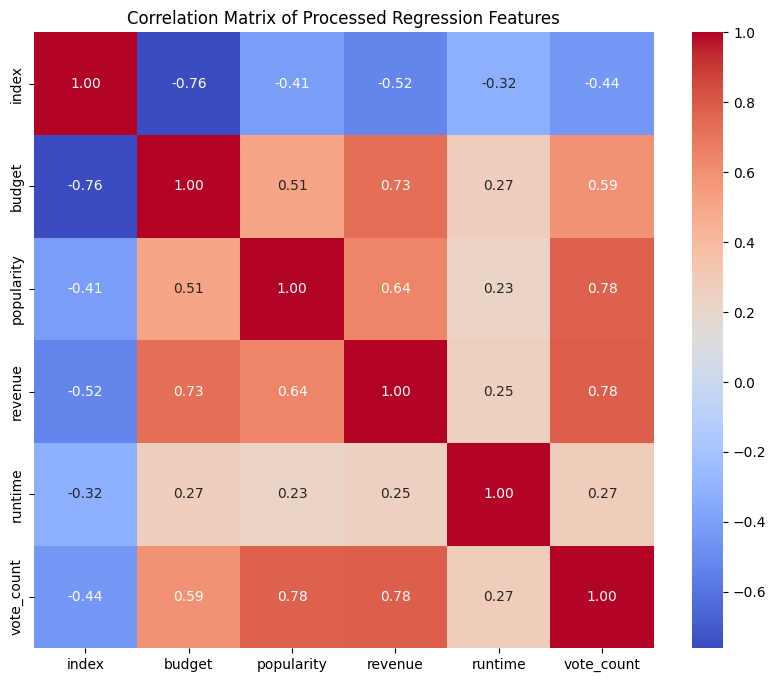

In [231]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the processed regression features
correlation_matrix_reg = X_processed_for_reg.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_reg, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Processed Regression Features')
plt.show()

In [232]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Ensure X_train_cls, X_test_cls, y_train_cls, y_test_cls are defined
# Re-define y_train_cls_binary and y_test_cls_binary
threshold = 7.0
y_train_cls_binary = (y_train_cls >= threshold).astype(int)
y_test_cls_binary = (y_test_cls >= threshold).astype(int)

# Select only numerical columns for filling NaN values with mean
X_train_cls_numeric = X_train_cls.select_dtypes(include=['int64', 'float64'])
X_test_cls_numeric = X_test_cls.select_dtypes(include=['int64', 'float64'])

# Fill any remaining NaN values in the numerical features with the mean of their columns
# Use the mean of the training data for both training and testing sets to prevent data leakage
X_train_cls_cleaned = X_train_cls_numeric.fillna(X_train_cls_numeric.mean())
X_test_cls_cleaned = X_test_cls_numeric.fillna(X_train_cls_numeric.mean())

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_cls_cleaned, y_train_cls_binary) # Use the binary target for fitting

y_pred_log = log_model.predict(X_test_cls_cleaned)
acc_log = accuracy_score(y_test_cls_binary, y_pred_log)
print(acc_log)

0.8220603537981269


In [233]:
#NAIVEBAYES CLASSIFICATION
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Re-define y_train_cls_binary and y_test_cls_binary to ensure they are available
threshold = 7.0
y_train_cls_binary = (y_train_cls >= threshold).astype(int)
y_test_cls_binary = (y_test_cls >= threshold).astype(int)

# Select only numerical columns for filling NaN values with mean
X_train_cls_numeric = X_train_cls.select_dtypes(include=['int64', 'float64'])
X_test_cls_numeric = X_test_cls.select_dtypes(include=['int64', 'float64'])

# Fill any remaining NaN values in the numerical features with the mean of their columns
# Use the mean of the training data for both training and testing sets to prevent data leakage
X_train_cls_cleaned = X_train_cls_numeric.fillna(X_train_cls_numeric.mean())
X_test_cls_cleaned = X_test_cls_numeric.fillna(X_train_cls_numeric.mean())

nb_model = GaussianNB()
nb_model.fit(X_train_cls_cleaned, y_train_cls_binary)
y_pred_nb = nb_model.predict(X_test_cls_cleaned)
acc_nb = accuracy_score(y_test_cls_binary, y_pred_nb)
print(acc_nb)

0.777315296566077


In [234]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Re-define y_train_cls_binary and y_test_cls_binary to ensure they are available
threshold = 7.0
y_train_cls_binary = (y_train_cls >= threshold).astype(int)
y_test_cls_binary = (y_test_cls >= threshold).astype(int)

# Select only numerical columns for filling NaN values with mean
X_train_cls_numeric = X_train_cls.select_dtypes(include=['int64', 'float64'])
X_test_cls_numeric = X_test_cls.select_dtypes(include=['int64', 'float64'])

# Fill any remaining NaN values in the numerical features with the mean of their columns
# Use the mean of the training data for both training and testing sets to prevent data leakage
X_train_cls_cleaned = X_train_cls_numeric.fillna(X_train_cls_numeric.mean())
X_test_cls_cleaned = X_test_cls_numeric.fillna(X_train_cls_numeric.mean())

knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_cls_cleaned, y_train_cls_binary)

y_pred_knn = knn_model.predict(X_test_cls_cleaned)

acc_knn = accuracy_score(y_test_cls_binary, y_pred_knn)
print(acc_knn)

0.7700312174817898


In [235]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'pd', 'url', 'df', 'X', 'y_reg', 'y_class', '_i2', '_i3', '_i4', 'StandardScaler', 'scaler', 'numerical_cols', '_i5', 'plt', 'sns', '_i6', '_i7', '_i8', 'corr', '_i9', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', 'temp_df', '_i18', 'train_test_split', 'X_train', 'X_test', 'y_train', 'y_test', '_i19', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', 'X_train_reg', 'X_test_reg', 'y_train_reg', 'y_test_reg', '_i36', 'LinearRegression', 'reg_model', 'y_pred_reg', '_i37', 'r2_score', 'mean_absolute_error', 'mean_squared_error', 'np', 'r2', 'mae', 'mse', 'rmse', '_i38', '_i39', 'X_cls_processed', 'X_train_cls', 'X_test_cls', 'y_train_cls', 'y_test_cls', '_i40', 'LogisticRegression',

In [236]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Re-define y_train_cls_binary and y_test_cls_binary to ensure they are available
threshold = 7.0
y_train_cls_binary = (y_train_cls >= threshold).astype(int)
y_test_cls_binary = (y_test_cls >= threshold).astype(int)

# Select only numerical columns for filling NaN values with mean
X_train_cls_numeric = X_train_cls.select_dtypes(include=['int64', 'float64'])
X_test_cls_numeric = X_test_cls.select_dtypes(include=['int64', 'float64'])

# Fill any remaining NaN values in the numerical features with the mean of their columns
# Use the mean of the training data for both training and testing sets to prevent data leakage
X_train_cls_cleaned = X_train_cls_numeric.fillna(X_train_cls_numeric.mean())
X_test_cls_cleaned = X_test_cls_numeric.fillna(X_train_cls_numeric.mean())

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_cls_cleaned, y_train_cls_binary)
y_pred_dt = dt_model.predict(X_test_cls_cleaned)
acc_dt = accuracy_score(y_test_cls_binary, y_pred_dt)
print(acc_dt)

0.7887617065556711


In [237]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Re-define y_train_cls_binary and y_test_cls_binary to ensure they are available
threshold = 7.0
y_train_cls_binary = (y_train_cls >= threshold).astype(int)
y_test_cls_binary = (y_test_cls >= threshold).astype(int)

# Select only numerical columns for filling NaN values with mean
X_train_cls_numeric = X_train_cls.select_dtypes(include=['int64', 'float64'])
X_test_cls_numeric = X_test_cls.select_dtypes(include=['int64', 'float64'])

# Fill any remaining NaN values in the numerical features with the mean of their columns
# Use the mean of the training data for both training and testing sets to prevent data leakage
X_train_cls_cleaned = X_train_cls_numeric.fillna(X_train_cls_numeric.mean())
X_test_cls_cleaned = X_test_cls_numeric.fillna(X_train_cls_numeric.mean())

rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
rf_model.fit(X_train_cls_cleaned, y_train_cls_binary)
y_pred_rf = rf_model.predict(X_test_cls_cleaned)
acc_rf = accuracy_score(y_test_cls_binary, y_pred_rf)
print(acc_rf)

0.8470343392299687


In [238]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "k-NN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        acc_log,
        acc_nb,
        acc_knn,
        acc_dt,
        acc_rf
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.822060
1          Naive Bayes  0.777315
2                 k-NN  0.770031
3        Decision Tree  0.788762
4        Random Forest  0.847034


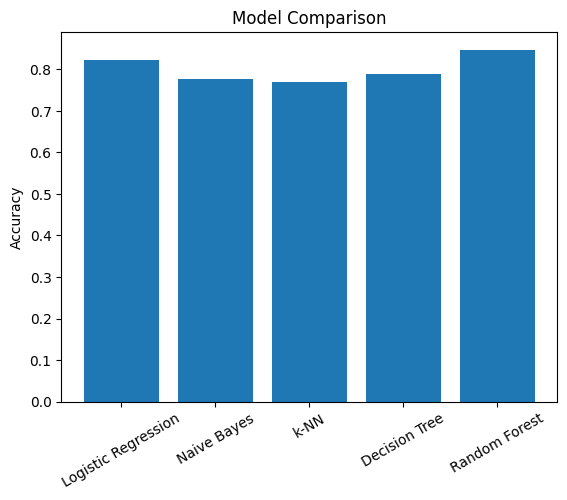

In [239]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["Accuracy"])
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

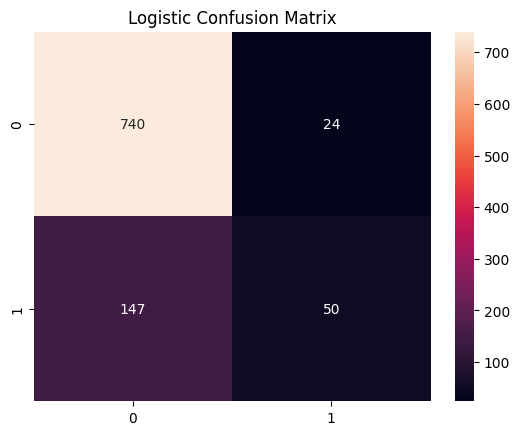

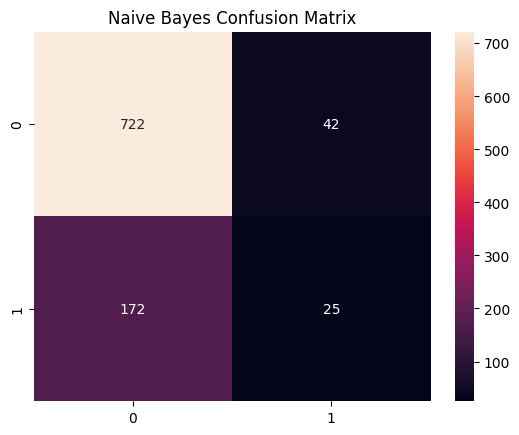

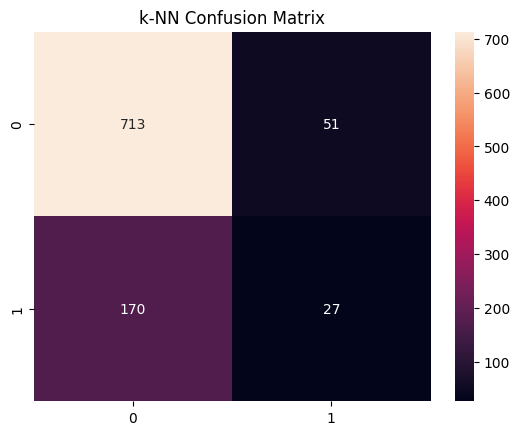

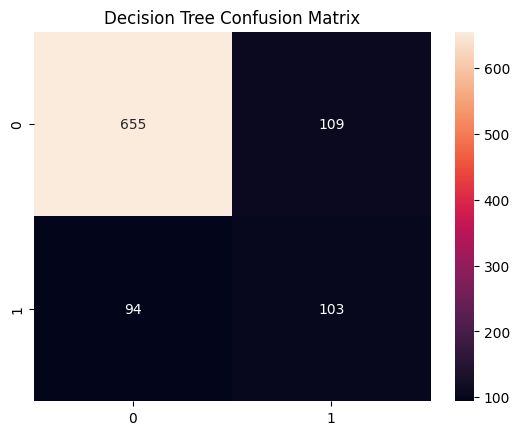

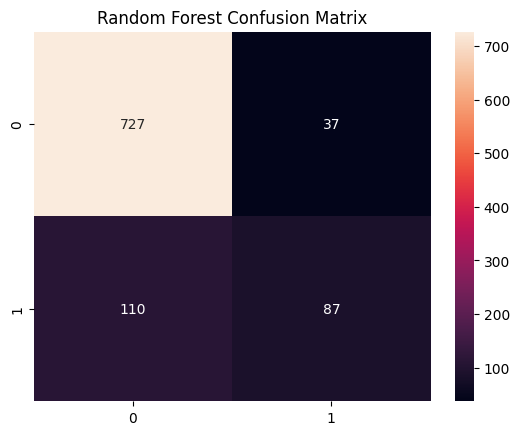

In [240]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

predictions = {
    "Logistic": y_pred_log,
    "Naive Bayes": y_pred_nb,
    "k-NN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, pred in predictions.items():
    cm = confusion_matrix(y_test_cls_binary, pred)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

CLUSTERING



In [241]:
print(X.columns)

Index(['index', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime', 'title',
       'vote_count', 'cast', 'director'],
      dtype='object')


In [242]:
from sklearn.cluster import KMeans

X_cluster = X[['budget', 'popularity']].fillna(0)

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

X_cluster['Cluster'] = clusters

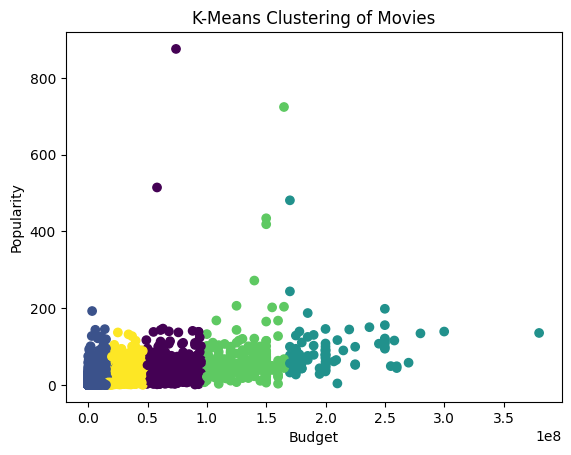

In [243]:
import matplotlib.pyplot as plt

plt.scatter(
    X_cluster['budget'],
    X_cluster['popularity'],
    c=X_cluster['Cluster']
)

plt.xlabel("Budget")
plt.ylabel("Popularity")
plt.title("K-Means Clustering of Movies")
plt.show()

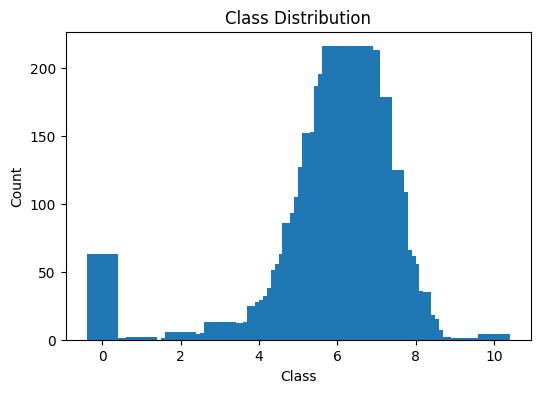

In [244]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(y_class)

classes = list(counts.keys())
frequencies = list(counts.values())

plt.figure(figsize=(6,4))
plt.bar(classes, frequencies)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

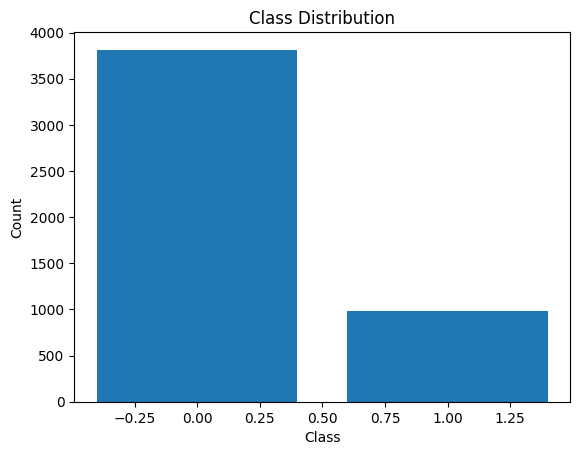

In [245]:
from collections import Counter
import matplotlib.pyplot as plt

y_binary = (df['vote_average'] >= 7).astype(int)

counts = Counter(y_binary)

plt.bar(counts.keys(), counts.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

LAB 11 : 13-05-2026

In [246]:
from sklearn.cluster import KMeans

X_cluster = X.select_dtypes(include=['int64', 'float64']).fillna(0)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

X_cluster["KMeans_Cluster"] = clusters

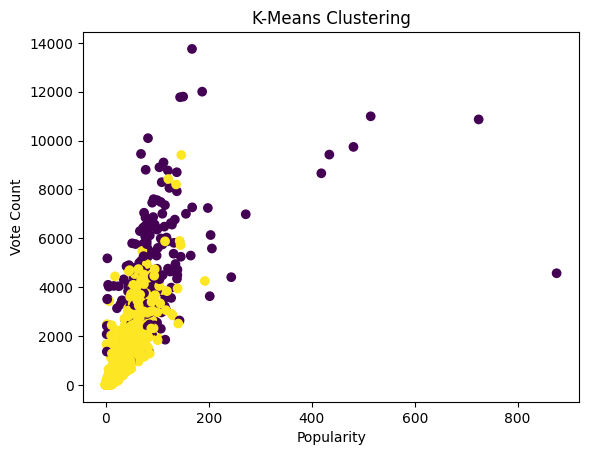

In [247]:
import matplotlib.pyplot as plt

plt.scatter(
    X_cluster["popularity"],
    X_cluster["vote_count"],
    c=X_cluster["KMeans_Cluster"]
)

plt.xlabel("Popularity")
plt.ylabel("Vote Count")
plt.title("K-Means Clustering")
plt.show()

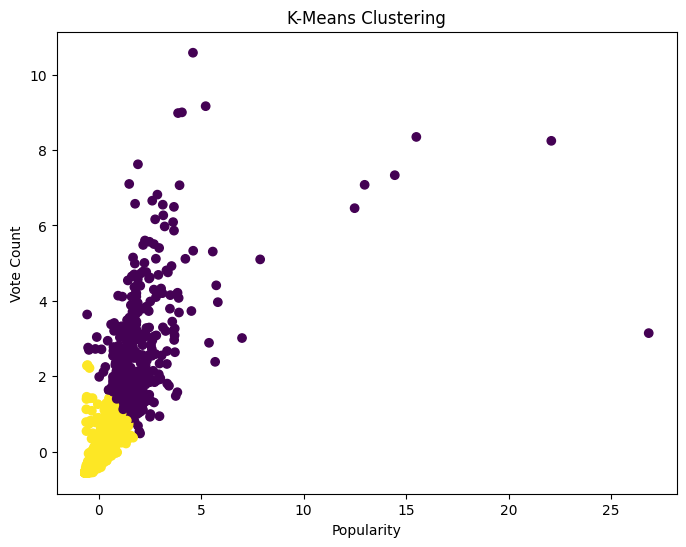

In [248]:
from sklearn.preprocessing import StandardScaler

X_plot = X[['popularity', 'vote_count']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_plot)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters
)

plt.xlabel("Popularity")
plt.ylabel("Vote Count")
plt.title("K-Means Clustering")
plt.show()

hierarchical clustering

In [249]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2)

hc_labels = hc.fit_predict(X_cluster)

X_cluster["HC_Cluster"] = hc_labels

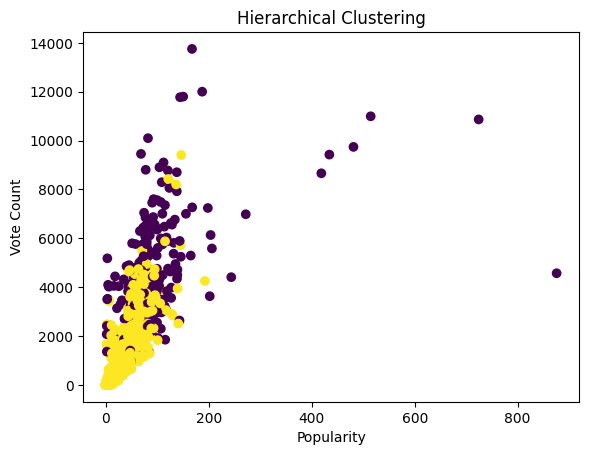

In [250]:
import matplotlib.pyplot as plt

plt.scatter(
    X_cluster["popularity"],
    X_cluster["vote_count"],
    c=X_cluster["HC_Cluster"]
)

plt.xlabel("Popularity")
plt.ylabel("Vote Count")
plt.title("Hierarchical Clustering")
plt.show()

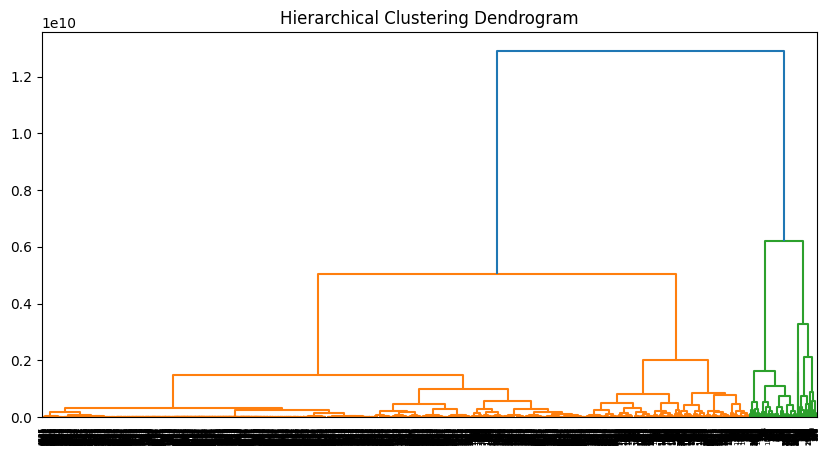

In [251]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(
    X_cluster.drop(["KMeans_Cluster", "HC_Cluster"], axis=1),
    method='ward'
)

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

dbscan

In [252]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_cluster)

X_cluster["DBSCAN_Cluster"] = dbscan_labels

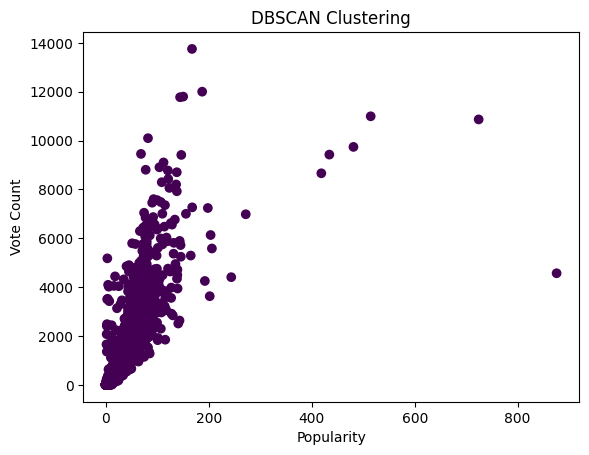

In [253]:
import matplotlib.pyplot as plt

plt.scatter(
    X_cluster["popularity"],
    X_cluster["vote_count"],
    c=X_cluster["DBSCAN_Cluster"]
)

plt.xlabel("Popularity")
plt.ylabel("Vote Count")
plt.title("DBSCAN Clustering")
plt.show()

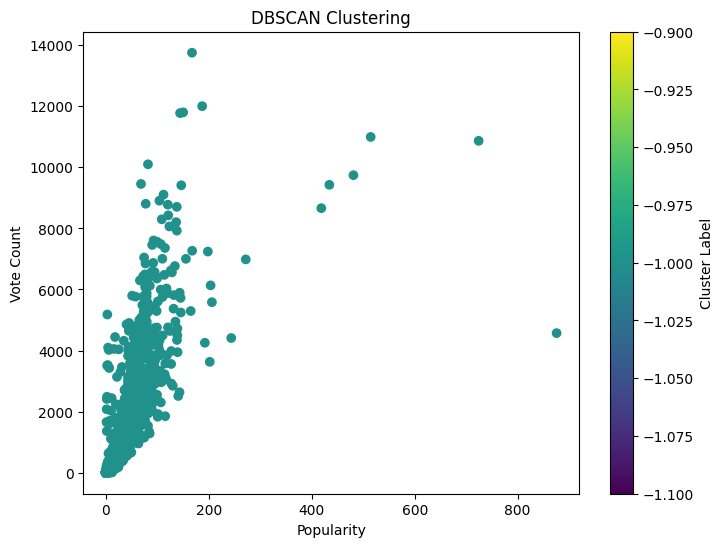

In [254]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

dbscan = DBSCAN(eps=0.4, min_samples=2)

dbscan_labels = dbscan.fit_predict(X_cluster)

X_cluster["DBSCAN_Cluster"] = dbscan_labels

plt.figure(figsize=(8,6))

plt.scatter(
    X_cluster["popularity"],
    X_cluster["vote_count"],
    c=X_cluster["DBSCAN_Cluster"],
    cmap='viridis'
)

plt.xlabel("Popularity")
plt.ylabel("Vote Count")
plt.title("DBSCAN Clustering")

plt.colorbar(label="Cluster Label")

plt.show()

PCA

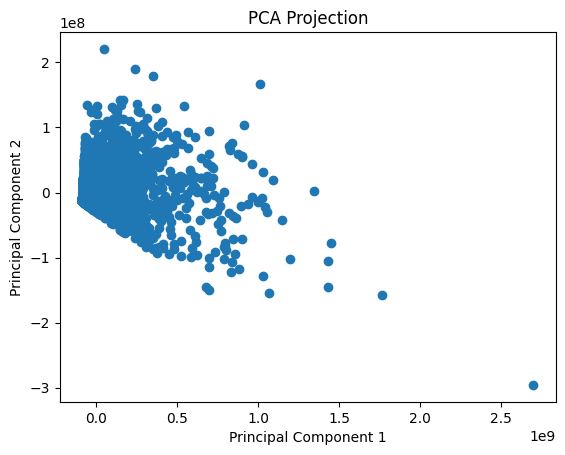

In [255]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_cluster.drop(
        ["KMeans_Cluster", "HC_Cluster", "DBSCAN_Cluster"],
        axis=1
    )
)

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")

plt.show()

In [256]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.97349474 0.02650526]


Remaining part of Lab 11

In [257]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

In [258]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.6973196939290525
MSE: 1.1643530881521733
RMSE: 1.0790519395062377
R2 Score: 0.2277993031168446


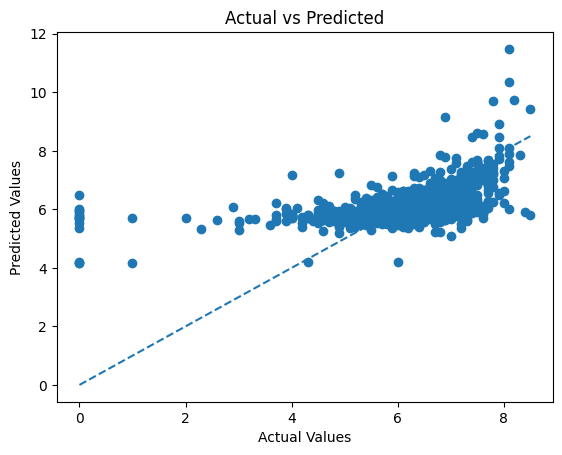

In [259]:
import matplotlib.pyplot as plt

plt.scatter(y_test_reg, y_pred_reg)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    linestyle='--'
)

plt.show()

In [260]:
print(X_train_cls.columns)

Index(['index', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime', 'title',
       'vote_count', 'cast', 'director'],
      dtype='object')


In [261]:
%whos

Variable                   Type                       Data/Info
---------------------------------------------------------------
AgglomerativeClustering    type                       <class 'sklearn.cluster._<...>AgglomerativeClustering'>
Counter                    type                       <class 'collections.Counter'>
DBSCAN                     type                       <class 'sklearn.cluster._dbscan.DBSCAN'>
DecisionTreeClassifier     ABCMeta                    <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
Dense                      type                       <class 'keras.src.layers.core.dense.Dense'>
GaussianNB                 ABCMeta                    <class 'sklearn.naive_bayes.GaussianNB'>
Input                      function                   <function Input at 0x7847c31f1e40>
KMeans                     ABCMeta                    <class 'sklearn.cluster._kmeans.KMeans'>
KNeighborsClassifier       ABCMeta                    <class 'sklearn.neighbors<...>on.KNeighbor

In [262]:
print(y_pred_log[:10])

[0 0 0 0 0 0 0 0 0 0]


In [263]:
print(y_test_cls[:10])

596     5.2
3372    5.7
2702    5.5
2473    6.7
8       7.4
577     5.5
3172    6.7
811     6.6
2077    6.7
4032    6.0
Name: vote_average, dtype: float64


In [264]:
print(y_test_cls.dtype)

float64


In [265]:
print(y_test_cls_binary[:10])

596     0
3372    0
2702    0
2473    0
8       1
577     0
3172    0
811     0
2077    0
4032    0
Name: vote_average, dtype: int64


In [266]:
from sklearn.metrics import classification_report

print(classification_report(y_test_cls_binary, y_pred_log))

              precision    recall  f1-score   support

           0       0.83      0.97      0.90       764
           1       0.68      0.25      0.37       197

    accuracy                           0.82       961
   macro avg       0.75      0.61      0.63       961
weighted avg       0.80      0.82      0.79       961



In [267]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_cls_binary, y_pred_log)
print(cm)

[[740  24]
 [147  50]]


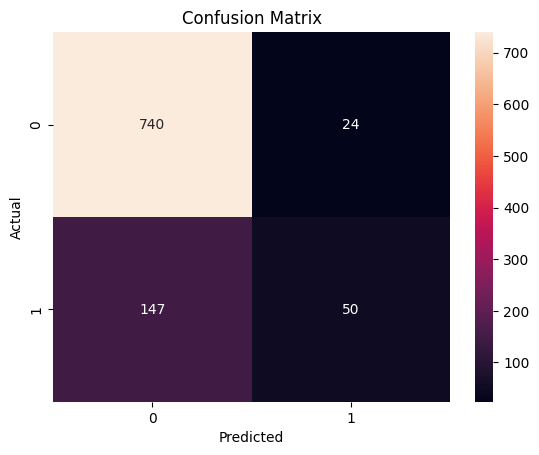

In [268]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls_binary, y_pred_log)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Cross validation

In [269]:
print(X.dtypes)

index                     int64
budget                    int64
genres                   object
keywords                 object
original_language        object
original_title           object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
title                    object
vote_count                int64
cast                     object
director                 object
dtype: object


In [270]:
X_numeric = X.select_dtypes(exclude=['object'])

print(X_numeric.columns)

Index(['index', 'budget', 'popularity', 'revenue', 'runtime', 'vote_count'], dtype='object')


In [271]:
print(X_numeric.isnull().sum())

index         0
budget        0
popularity    0
revenue       0
runtime       2
vote_count    0
dtype: int64


In [272]:
X_numeric = X_numeric.fillna(X_numeric.mean())

In [273]:
print(y_class[:10])
print(y_class.dtype)

0    7.2
1    6.9
2    6.3
3    7.6
4    6.1
5    5.9
6    7.4
7    7.3
8    7.4
9    5.7
Name: vote_average, dtype: float64
float64


In [274]:
print(y_binary[:10])

0    1
1    0
2    0
3    1
4    0
5    0
6    1
7    1
8    1
9    0
Name: vote_average, dtype: int64


In [275]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    cls_model,
    X_numeric,
    y_binary,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.81581686 0.82101977 0.8251821  0.8125     0.8       ]
Average Accuracy: 0.8149037460978148


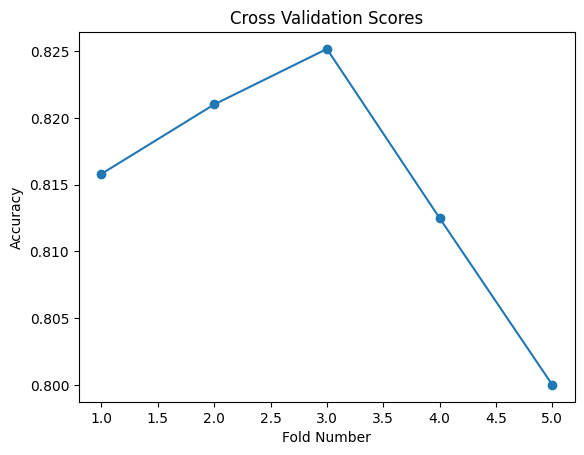

In [276]:
import matplotlib.pyplot as plt

plt.plot(range(1,6), scores, marker='o')
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Cross Validation Scores")
plt.show()

In [277]:
X_train_cls_num = X_train_cls.select_dtypes(exclude=['object'])
X_test_cls_num = X_test_cls.select_dtypes(exclude=['object'])

print(X_train_cls_num.columns)

Index(['index', 'budget', 'popularity', 'revenue', 'runtime', 'vote_count'], dtype='object')


In [278]:
print(X_train_cls_num.isnull().sum())

index         0
budget        0
popularity    0
revenue       0
runtime       1
vote_count    0
dtype: int64


In [279]:
X_train_cls_num = X_train_cls_num.fillna(0)
X_test_cls_num = X_test_cls_num.fillna(0)

In [280]:
from sklearn.linear_model import LogisticRegression

cls_model = LogisticRegression(max_iter=1000)

cls_model.fit(X_train_cls_num, y_train_cls_binary)

LogisticRegression(max_iter=1000)

In [281]:
print("Model Trained Successfully")

Model Trained Successfully


In [282]:
y_pred_cls = cls_model.predict(X_test_cls_num)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_cls_binary, y_pred_cls)

print("Accuracy:", accuracy)

Accuracy: 0.8220603537981269


In [283]:
from sklearn.metrics import classification_report

print(classification_report(y_test_cls_binary, y_pred_cls))

              precision    recall  f1-score   support

           0       0.83      0.97      0.90       764
           1       0.68      0.25      0.37       197

    accuracy                           0.82       961
   macro avg       0.75      0.61      0.63       961
weighted avg       0.80      0.82      0.79       961



In [284]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_cls_binary, y_pred_cls)
print(cm)

[[740  24]
 [147  50]]


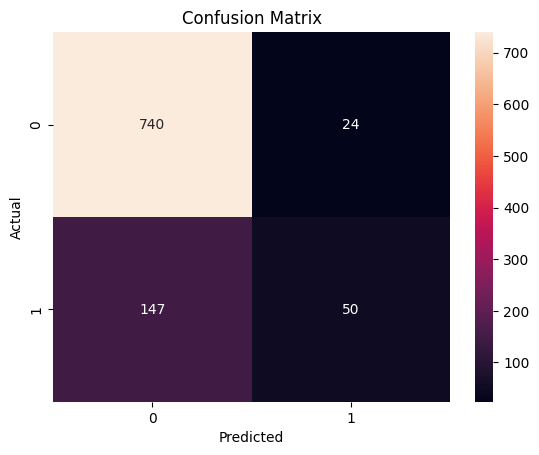

In [285]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

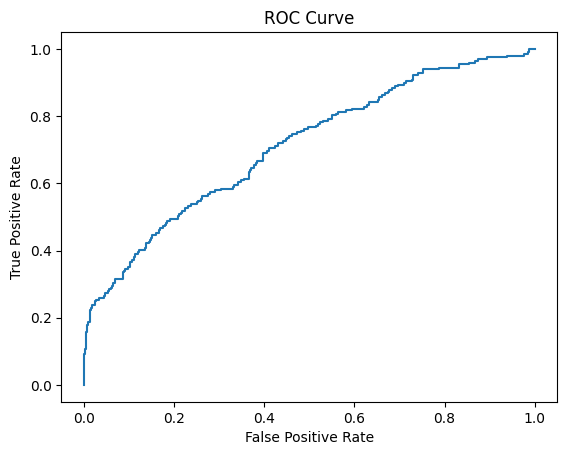

AUC: 0.7097828686847212


In [286]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = cls_model.predict_proba(X_test_cls_num)[:,1]

fpr, tpr, thresholds = roc_curve(y_test_cls_binary, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc)

Lab 12 : Neural Networks

In [287]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y_binary,
    test_size=0.2,
    random_state=42
)

In [288]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [289]:
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [290]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [291]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7361 - loss: 793599.5000 - val_accuracy: 0.7711 - val_loss: 78099.1875
Epoch 2/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7371 - loss: 50122.1875 - val_accuracy: 0.7932 - val_loss: 81493.7891
Epoch 3/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7358 - loss: 32678.7227 - val_accuracy: 0.7347 - val_loss: 25938.8262
Epoch 4/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7335 - loss: 30489.1641 - val_accuracy: 0.7672 - val_loss: 8825.9697
Epoch 5/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7035 - loss: 39068.5078 - val_accuracy: 0.6541 - val_loss: 23556.9785
Epoch 6/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7175 - loss: 27864.5098 - val_accuracy: 0.7932 - val_loss: 57752.8281
Epoch 7/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7309 - loss: 42641.2070 - val_accuracy: 0.7776 - val_loss: 64054.9844
Epoch 8/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/s

In [292]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7950 - loss: 0.5081 
Test Accuracy: 0.795005202293396
Test Loss: 0.5081431865692139


In [293]:
predictions = model.predict(X_test)

predicted_classes = (predictions > 0.5).astype(int)

print(predicted_classes[:10])

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


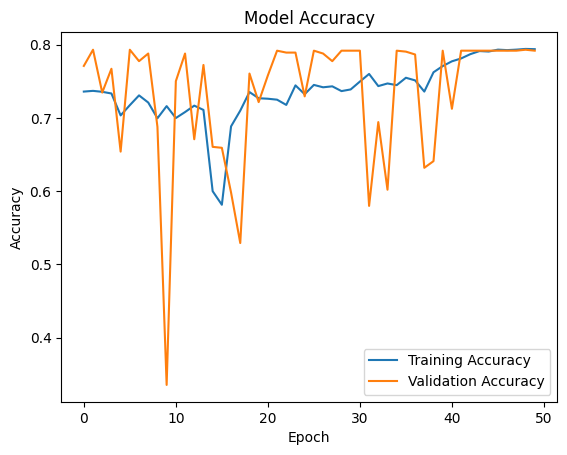

In [294]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

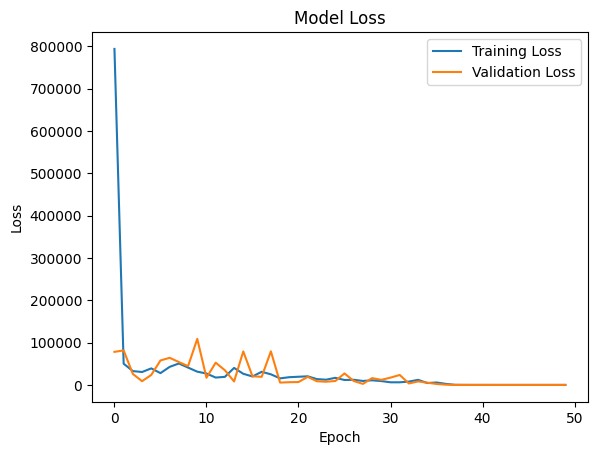

In [295]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

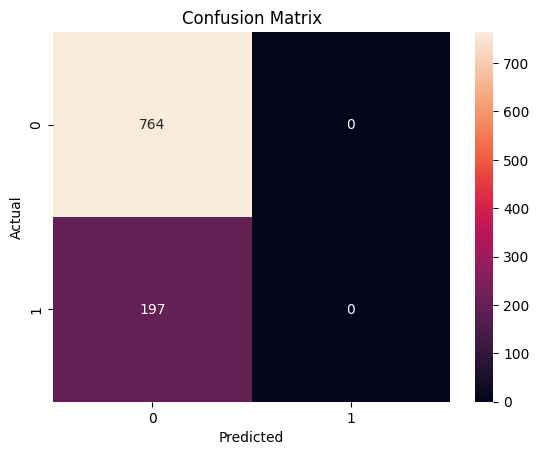

In [296]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [297]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89       764
           1       0.00      0.00      0.00       197

    accuracy                           0.80       961
   macro avg       0.40      0.50      0.44       961
weighted avg       0.63      0.80      0.70       961



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [298]:
import numpy as np

print(np.unique(predicted_classes, return_counts=True))

(array([0]), array([961]))


In [299]:
print(y_train.value_counts())

vote_average
0    3051
1     791
Name: count, dtype: int64


In [300]:
print(X_train.shape)
print(y_train.shape)

(3842, 6)
(3842,)


In [301]:
print(predictions[:20])

[[0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.19650324]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]
 [0.20795764]]


In [302]:
print(history.history['accuracy'][-5:])
print(history.history['val_accuracy'][-5:])

[0.7933615446090698, 0.7927107214927673, 0.7933615446090698, 0.794337809085846, 0.7940123677253723]
[0.7919375896453857, 0.7919375896453857, 0.7919375896453857, 0.7932379841804504, 0.7919375896453857]


In [303]:
print(history.history['loss'][-5:])
print(history.history['val_loss'][-5:])

[0.6551133394241333, 0.5458049774169922, 0.5199342966079712, 0.5161817669868469, 0.5237166285514832]
[0.5157300233840942, 0.5341932773590088, 0.5510267019271851, 0.5144343972206116, 0.5180701613426208]


In [304]:
print(predictions.min())
print(predictions.max())
print(predictions.mean())

0.035163272
0.20795767
0.20636852


In [305]:
import numpy as np

predicted_classes = (predictions > 0.2).astype(int)

print(np.unique(predicted_classes, return_counts=True))

(array([0, 1]), array([ 26, 935]))


In [306]:
from sklearn.metrics import accuracy_score

predicted_classes = (predictions > 0.2).astype(int)

print("Accuracy:", accuracy_score(y_test, predicted_classes))

Accuracy: 0.21748178980228927


In [307]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.73      0.02      0.05       764
           1       0.20      0.96      0.34       197

    accuracy                           0.22       961
   macro avg       0.47      0.49      0.19       961
weighted avg       0.62      0.22      0.11       961



Actual Testing

In [308]:
print(type(cosine_sim))
print(cosine_sim.shape)

<class 'numpy.ndarray'>
(4803, 4803)


In [310]:
for name in globals():
    if "recommend" in name.lower():
        print(name)

In [311]:
print(df['title'].head(20))

0                                          Avatar
1        Pirates of the Caribbean: At World's End
2                                         Spectre
3                           The Dark Knight Rises
4                                     John Carter
5                                    Spider-Man 3
6                                         Tangled
7                         Avengers: Age of Ultron
8          Harry Potter and the Half-Blood Prince
9              Batman v Superman: Dawn of Justice
10                               Superman Returns
11                              Quantum of Solace
12     Pirates of the Caribbean: Dead Man's Chest
13                                The Lone Ranger
14                                   Man of Steel
15       The Chronicles of Narnia: Prince Caspian
16                                   The Avengers
17    Pirates of the Caribbean: On Stranger Tides
18                                 Men in Black 3
19      The Hobbit: The Battle of the Five Armies


In [312]:
def recommend_movie(movie_name):

    movie_index = df[df['title'] == movie_name].index[0]

    distances = cosine_sim[movie_index]

    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    for movie in movies_list:
        print(df.iloc[movie[0]].title)

In [313]:
recommend_movie("Avatar")

Superman Returns
Man of Steel
X-Men: Days of Future Past
Jupiter Ascending
The Wolverine


In [314]:
recommend_movie("The Avengers")

Avengers: Age of Ultron
The Avengers
Captain America: Civil War
Iron Man 3
Transformers: Revenge of the Fallen


In [315]:
def recommend_movie(movie_name):
    movie_index = df[df['title'] == movie_name].index[0]

    distances = cosine_sim[movie_index]

    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:11]

    print("Recommended Movies:\n")

    for movie in movies_list:
        print(df.iloc[movie[0]].title)

In [316]:
recommend_movie("Avatar")

Recommended Movies:

Superman Returns
Man of Steel
X-Men: Days of Future Past
Jupiter Ascending
The Wolverine
Superman
Superman II
Beastmaster 2: Through the Portal of Time
Teenage Mutant Ninja Turtles
Mystery Men
